IMPORTS


In [119]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

READ

In [120]:
df = pd.read_csv('placement.csv')

In [121]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [122]:
df.shape

(200, 2)

Text(0, 0.5, 'Package(in lpa)')

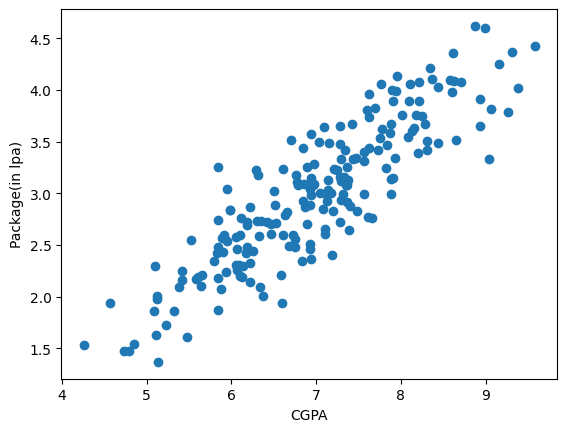

In [123]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [124]:
X = df.iloc[:,0:1]
#X = df.iloc[:,[0]]   <- all row and one column only XD hehe
y = df.iloc[:,[-1]]

In [125]:
X.shape,y.shape

((200, 1), (200, 1))

printing x and y


In [126]:
print(y,"\n\n\n\n\n\n",X)

     package
0       3.26
1       1.98
2       3.25
3       3.67
4       3.57
..       ...
195     2.46
196     2.57
197     3.24
198     3.96
199     2.33

[200 rows x 1 columns] 





      cgpa
0    6.89
1    5.12
2    7.82
3    7.42
4    6.94
..    ...
195  6.93
196  5.89
197  7.21
198  7.63
199  6.22

[200 rows x 1 columns]


train test split

In [127]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

#linear reg.

In [128]:
from sklearn.linear_model import LinearRegression

In [129]:
lr = LinearRegression()

In [130]:
lr.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'Package(in lpa)')

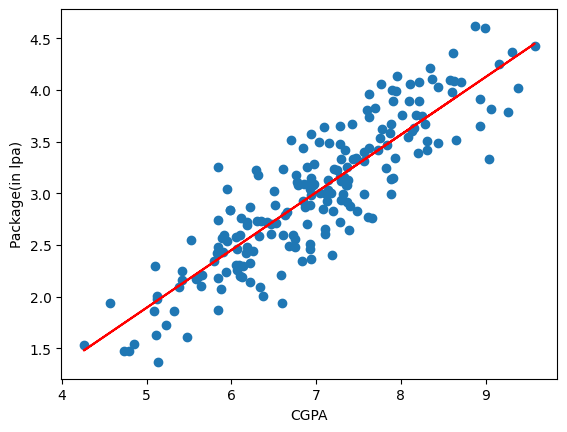

In [131]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(X_train,lr.predict(X_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

#Metrics

In [132]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [133]:
y_pred = lr.predict(X_test) # putting the predicted value of X_test in Y_pred

In [134]:
y_test.values

array([[4.1 ],
       [3.49],
       [2.08],
       [2.33],
       [1.94],
       [1.48],
       [1.86],
       [3.09],
       [4.21],
       [2.87],
       [3.65],
       [4.  ],
       [2.89],
       [2.6 ],
       [2.99],
       [3.25],
       [1.86],
       [3.67],
       [2.37],
       [3.42],
       [2.48],
       [3.65],
       [2.6 ],
       [2.83],
       [4.08],
       [2.56],
       [3.58],
       [3.81],
       [4.09],
       [2.01],
       [3.63],
       [2.92],
       [3.51],
       [1.94],
       [2.21],
       [3.34],
       [3.34],
       [3.23],
       [2.01],
       [2.61]])

#Mean Absolute Error

In [135]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


#Mean Squared Error

In [136]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


#Root Mean Square Error

In [137]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


#R2 Score



In [138]:
print("R2",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 0.780730147510384


# Adjusted R2 score

In [139]:
# Adjusted R2 score
X_test.shape

(40, 1)

In [140]:
1 - ((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

#adding a new column (with 0 corelation with package)

In [141]:
new_df1 = df.copy()
new_df1['random_feature'] = np.random.random(200)
new_df1.head()

,cgpa,package,random_feature
0,6.89,3.26,0.153890
1,5.12,1.98,0.995824
2,7.82,3.25,0.278698
3,7.42,3.67,0.721521
4,6.94,3.57,0.765242


In [142]:
new_df1 = new_df1[['cgpa','random_feature','package']]
new_df1.head()

,cgpa,random_feature,package
0,6.89,0.153890,3.26
1,5.12,0.995824,1.98
2,7.82,0.278698,3.25
3,7.42,0.721521,3.67
4,6.94,0.765242,3.57


In [143]:
new_df1.corr()

,cgpa,random_feature,package
cgpa,1.000000,-0.129490,0.880692
random_feature,-0.129490,1.000000,-0.082938
package,0.880692,-0.082938,1.000000


Text(0, 0.5, 'Package(in lpa)')

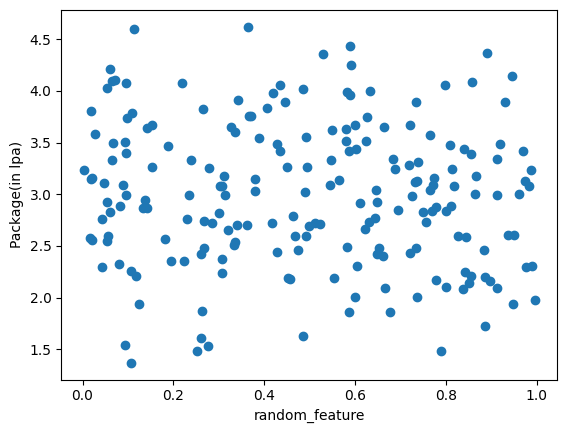

In [144]:
plt.scatter(new_df1['random_feature'],new_df1['package'])
plt.xlabel('random_feature')
plt.ylabel('Package(in lpa)')

In [145]:
X = new_df1.iloc[:,0:2]
y = new_df1.iloc[:,-1]

In [146]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

model trained on random feature

In [147]:
lr = LinearRegression()

In [148]:
lr.fit(X_train,y_train)

LinearRegression()

In [149]:
y_pred = lr.predict(X_test)

In [150]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.7807040690171407


r2 score got decreases

In [151]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.7688502349099592

adding a new column to the data frame which as a corelation with package

In [152]:
new_df2 = df.copy()

new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12,200)/10)

new_df2 = new_df2[['cgpa','iq','package']]

In [153]:
new_df2.sample(5)

,cgpa,iq,package
136,5.64,1.30,2.10
157,6.47,1.50,2.70
108,7.76,3.94,3.54
74,6.85,3.54,3.44
81,6.10,2.00,2.20


In [161]:
new_df2.corr()

,cgpa,iq,package
cgpa,1.000000,0.672906,0.880692
iq,0.672906,1.000000,0.753178
package,0.880692,0.753178,1.000000


Text(0, 0.5, 'Package(in lpa)')

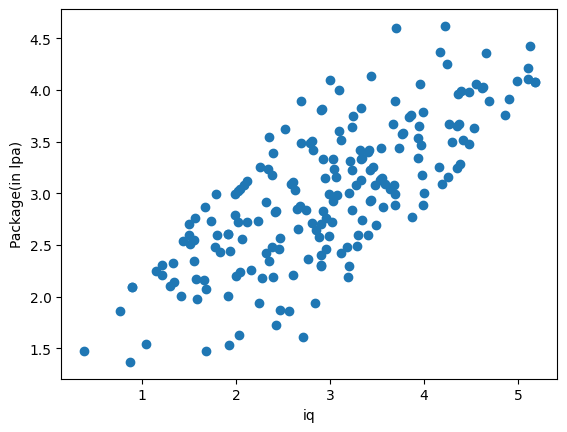

In [154]:
plt.scatter(new_df2['iq'],new_df2['package'])
plt.xlabel('iq')
plt.ylabel('Package(in lpa)')

In [155]:
np.random.randint(-100,100)

-97

In [156]:
X = new_df2.iloc[:,0:2]
y = new_df2.iloc[:,-1]

In [157]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [158]:
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)

r2 got increase

In [159]:
print("R2 score",r2_score(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

R2 score 0.8316147852311598


In [160]:
1 - ((1-r2)*(40-1)/(40-1-2))

0.8225128817301415